# Hedonic Pricing — Thesis Figures
Publication-ready charts for the thesis. Run `hedonic_regression.ipynb` first to generate the tables.

**Figures:**
1. Price distribution by brand tier (violin plots) — now 5 tiers (4 quadrants + generic)
2. Coefficient forest plot (pooled regression) — includes `is_premium`, `is_high_recognition`
3. Brand premium: marked vs. final price
4. Premium heatmap across categories x attributes
5. Promotion penetration vs. brand premium (scatter)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from scipy import stats

from src.brand_quadrants import QUADRANT_LABELS

# Colorblind-safe palette (Wong 2011)
COLORS = {
    'blue':   '#0072B2',
    'orange': '#E69F00',
    'green':  '#009E73',
    'red':    '#D55E00',
    'purple': '#CC79A7',
    'sky':    '#56B4E9',
    'yellow': '#F0E442',
    'black':  '#000000',
}

QUADRANT_COLORS = {
    'household_giant': '#2196F3',
    'prestige_leader': '#FF9800',
    'niche_professional': '#9C27B0',
    'local_value': '#4CAF50',
    'generic': '#999999',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from pathlib import Path
from src.utils import PROJECT_ROOT
OUT = PROJECT_ROOT / 'output'

In [2]:
from src.preparation import prepare_regression_sample

df = pd.read_csv(OUT / 'product_features.csv')
print(f"{len(df)} products loaded")

reg_df, reg_df_clean = prepare_regression_sample(df)
print(f"Regression sample: {len(reg_df)} products (winsorized)")
print(f"OLS-ready sample:  {len(reg_df_clean)} products (model columns complete)")

2280 products loaded
Regression sample: 2032 products (winsorized)
OLS-ready sample:  2032 products (model columns complete)


## Figure 1: Price Distribution by Brand Quadrant
Violin plots comparing unit prices across the 4 brand quadrants + generic.

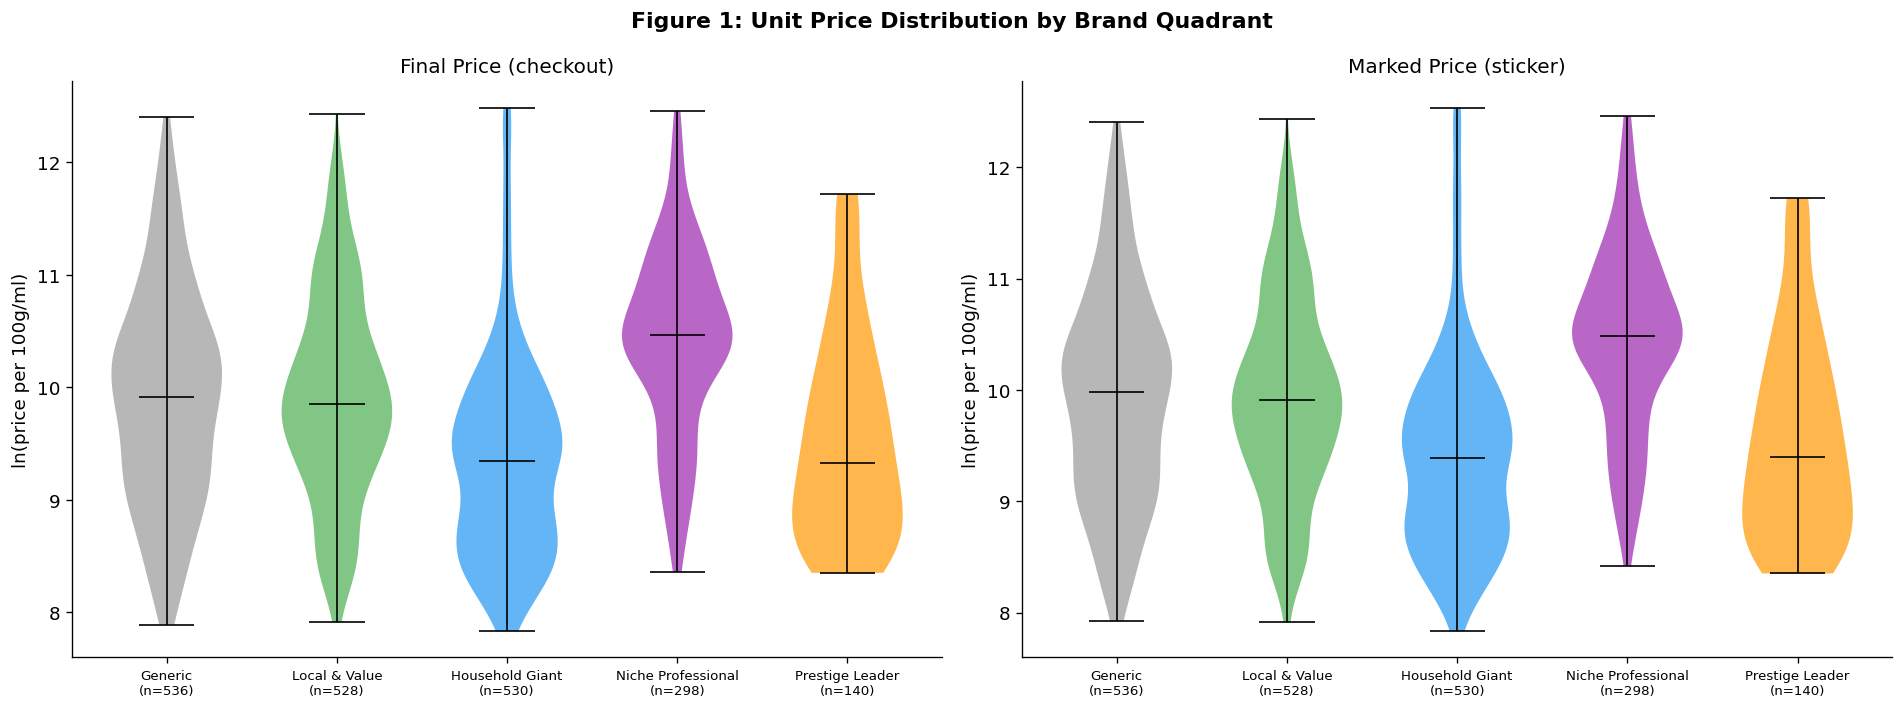

Saved Fig 1


In [3]:
# Assign brand_quadrant label for plotting
TIER_ORDER = ['generic', 'local_value', 'household_giant', 'niche_professional', 'prestige_leader']
TIER_LABELS = {
    'generic': 'Generic',
    'local_value': 'Local & Value',
    'household_giant': 'Household Giant',
    'niche_professional': 'Niche Professional',
    'prestige_leader': 'Prestige Leader',
}

# Ensure brand_quadrant column exists
if 'brand_quadrant' not in reg_df.columns:
    reg_df['brand_quadrant'] = 'generic'
    reg_df.loc[reg_df['is_branded'] == 1, 'brand_quadrant'] = 'branded'

# Fill unbranded as 'generic'
reg_df['brand_quadrant'] = reg_df['brand_quadrant'].fillna('').replace('', 'generic')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, col, title in zip(
    axes,
    ['ln_price_per_unit', 'ln_marked_price_per_unit'],
    ['Final Price (checkout)', 'Marked Price (sticker)'],
):
    # Collect data per tier
    data_plot = []
    labels = []
    colors_plot = []
    for tier in TIER_ORDER:
        vals = reg_df[reg_df['brand_quadrant'] == tier][col].dropna().values
        if len(vals) > 0:
            data_plot.append(vals)
            labels.append(f"{TIER_LABELS[tier]}\n(n={len(vals)})")
            colors_plot.append(QUADRANT_COLORS[tier])

    positions = np.arange(1, len(data_plot) + 1)
    vp = ax.violinplot(data_plot, positions=positions, showmedians=True, widths=0.65)

    for j, body in enumerate(vp['bodies']):
        body.set_facecolor(colors_plot[j])
        body.set_alpha(0.7)
    for pc in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        vp[pc].set_color('black')
        vp[pc].set_linewidth(1)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('ln(price per 100g/ml)')
    ax.set_title(title)

fig.suptitle('Figure 1: Unit Price Distribution by Brand Quadrant', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'thesis_fig1_brand_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Fig 1")

In [4]:
# --- Table for Fig 1: Branded vs. Generic price comparison by category ---
from scipy.stats import mannwhitneyu

cat_order = sorted(reg_df['parent_category'].unique())

rows = []
for price_col, price_label in [
    ('ln_price_per_unit', 'final'),
    ('ln_marked_price_per_unit', 'marked'),
]:
    for cat in cat_order:
        sub = reg_df[reg_df['parent_category'] == cat]
        br = sub[sub['is_branded'] == 1][price_col].dropna()
        ge = sub[sub['is_branded'] == 0][price_col].dropna()
        if len(br) < 2 or len(ge) < 2:
            continue
        med_br, med_ge = br.median(), ge.median()
        gap_pct = (np.exp(med_br) - np.exp(med_ge)) / np.exp(med_ge) * 100
        U, p = mannwhitneyu(br, ge, alternative='two-sided')
        rows.append({
            'category': cat,
            'price_type': price_label,
            'n_branded': len(br),
            'n_generic': len(ge),
            'median_branded': round(med_br, 4),
            'median_generic': round(med_ge, 4),
            'mean_branded': round(br.mean(), 4),
            'mean_generic': round(ge.mean(), 4),
            'price_gap_pct': round(gap_pct, 1),
            'mann_whitney_U': int(U),
            'mann_whitney_p': round(p, 4),
        })

table_fig1 = pd.DataFrame(rows)
table_fig1.to_csv(OUT / 'thesis_table_brand_distribution.csv', index=False, encoding='utf-8-sig')
print("Table for Fig 1: Branded vs. Generic Unit Prices")
print(f"Saved → output/thesis_table_brand_distribution.csv\n")
table_fig1

Table for Fig 1: Branded vs. Generic Unit Prices
Saved → output/thesis_table_brand_distribution.csv



,category,price_type,n_branded,n_generic,median_branded,median_generic,mean_branded,mean_generic,price_gap_pct,mann_whitney_U,mann_whitney_p
0,Bánh Kẹo,final,320,230,10.4799,10.2999,10.4981,10.3489,19.7,40602,0.0386
1,Gia Vị,final,273,21,9.3757,9.1313,9.3402,9.5617,27.7,2571,0.4320
2,Mì - Thực Phẩm Ăn Liền,final,189,35,9.4114,9.3887,9.4372,9.5151,2.3,3208,0.7797
3,Rau - Củ - Trái Cây,final,16,108,9.4140,9.1031,9.5516,9.1983,36.5,1157,0.0292
4,Sữa Tươi,final,293,37,8.7740,9.0581,9.1798,9.6215,-24.7,3524,0.0005
5,Thực Phẩm Chế Biến,final,140,27,9.9341,9.3177,10.0067,9.5701,85.2,2591,0.0023
6,Thực Phẩm Khô,final,127,43,10.3049,10.3083,10.3294,10.2629,-0.3,2787,0.8409
7,Thực Phẩm Đông Lạnh,final,99,32,9.9363,10.1055,10.0384,10.1703,-15.6,1379,0.2733
8,Trứng - Đậu Hũ,final,6,2,8.4724,8.2669,8.5229,8.2669,22.8,9,0.4286
9,Bánh Kẹo,marked,320,230,10.4864,10.3193,10.5400,10.3777,18.2,41000,0.0223


## Figure 2: Coefficient Forest Plot
All key regressors from the pooled OLS, with 95% CIs. Cluster-robust SEs.

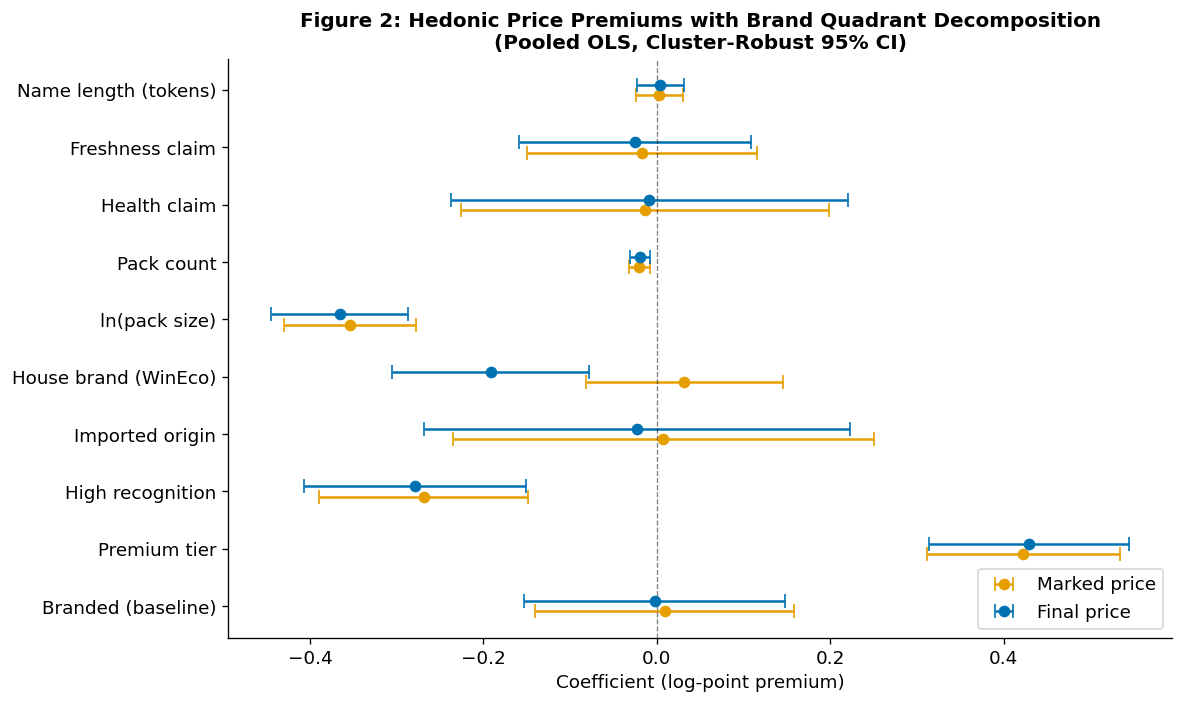

Saved Fig 2


In [5]:
FORMULA = (
    'ln_price_per_unit ~ '
    'is_branded + is_premium + is_high_recognition + '
    'is_import + is_house_brand + '
    'ln_pack_size + pack_count + '
    'has_health_claim + has_freshness_claim + '
    'name_length + C(subcategory)'
)

model_final  = smf.ols(FORMULA, data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['subcategory'].astype(str)})
model_marked = smf.ols(FORMULA.replace('ln_price_per_unit', 'ln_marked_price_per_unit'),
                        data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['subcategory'].astype(str)})

KEY_VARS = [
    ('is_branded',          'Branded (baseline)'),
    ('is_premium',          'Premium tier'),
    ('is_high_recognition', 'High recognition'),
    ('is_import',           'Imported origin'),
    ('is_house_brand',      'House brand (WinEco)'),
    ('ln_pack_size',        'ln(pack size)'),
    ('pack_count',          'Pack count'),
    ('has_health_claim',    'Health claim'),
    ('has_freshness_claim', 'Freshness claim'),
    ('name_length',         'Name length (tokens)'),
]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(KEY_VARS))
offset = 0.18

for i, (mod, label, color) in enumerate([
    (model_marked, 'Marked price', COLORS['orange']),
    (model_final,  'Final price',  COLORS['blue']),
]):
    coefs = [mod.params.get(v, np.nan) for v, _ in KEY_VARS]
    cis   = [mod.conf_int().loc[v].values if v in mod.params else [np.nan, np.nan]
             for v, _ in KEY_VARS]
    lo_ci = [c[0] for c in cis]
    hi_ci = [c[1] for c in cis]

    y = y_pos + (i - 0.5) * offset
    ax.errorbar(
        coefs, y,
        xerr=[np.array(coefs) - np.array(lo_ci), np.array(hi_ci) - np.array(coefs)],
        fmt='o', color=color, capsize=4, markersize=6, label=label,
        linewidth=1.5,
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([label for _, label in KEY_VARS])
ax.set_xlabel('Coefficient (log-point premium)')
ax.set_title('Figure 2: Hedonic Price Premiums with Brand Quadrant Decomposition\n'
             '(Pooled OLS, Cluster-Robust 95% CI)',
             fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT / 'thesis_fig2_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Fig 2")

In [6]:
# --- Table for Fig 2: Pooled coefficients with CIs and % premiums ---
rows_f2 = []
for var, label in KEY_VARS:
    row = {'variable': label}
    for mod, suffix in [(model_final, 'final'), (model_marked, 'marked')]:
        beta = mod.params.get(var, np.nan)
        se = mod.bse.get(var, np.nan)
        ci = mod.conf_int().loc[var].values if var in mod.params else [np.nan, np.nan]
        pval = mod.pvalues.get(var, np.nan)
        pct = (np.exp(beta) - 1) * 100  # convert log-points to %
        row[f'beta_{suffix}'] = round(beta, 4)
        row[f'se_{suffix}'] = round(se, 4)
        row[f'ci_lo_{suffix}'] = round(ci[0], 4)
        row[f'ci_hi_{suffix}'] = round(ci[1], 4)
        row[f'pval_{suffix}'] = round(pval, 4)
        row[f'pct_premium_{suffix}'] = round(pct, 1)
    rows_f2.append(row)

table_fig2 = pd.DataFrame(rows_f2)
table_fig2.to_csv(OUT / 'thesis_table_forest_plot.csv', index=False, encoding='utf-8-sig')
print("Table for Fig 2: Pooled Hedonic Coefficients with 95% CIs")
print("pct_premium = (exp(beta) - 1) * 100  -- interpretable % price effect\n")
print(f"Saved -> output/thesis_table_forest_plot.csv\n")
table_fig2

Table for Fig 2: Pooled Hedonic Coefficients with 95% CIs
pct_premium = (exp(beta) - 1) * 100  -- interpretable % price effect

Saved -> output/thesis_table_forest_plot.csv



,variable,beta_final,se_final,ci_lo_final,ci_hi_final,pval_final,pct_premium_final,beta_marked,se_marked,ci_lo_marked,ci_hi_marked,pval_marked,pct_premium_marked
0,Branded (baseline),-0.0026,0.0766,-0.1527,0.1475,0.9730,-0.3,0.0090,0.0760,-0.1400,0.1580,0.9057,0.9
1,Premium tier,0.4293,0.0591,0.3135,0.5450,0.0000,53.6,0.4225,0.0568,0.3112,0.5338,0.0000,52.6
2,High recognition,-0.2790,0.0653,-0.4069,-0.1510,0.0000,-24.3,-0.2690,0.0616,-0.3898,-0.1482,0.0000,-23.6
3,Imported origin,-0.0229,0.1253,-0.2685,0.2226,0.8547,-2.3,0.0074,0.1239,-0.2353,0.2502,0.9522,0.7
4,House brand (WinEco),-0.1917,0.0581,-0.3056,-0.0778,0.0010,-17.4,0.0316,0.0580,-0.0820,0.1452,0.5860,3.2
5,ln(pack size),-0.3658,0.0403,-0.4448,-0.2868,0.0000,-30.6,-0.3540,0.0388,-0.4300,-0.2781,0.0000,-29.8
6,Pack count,-0.0195,0.0061,-0.0314,-0.0076,0.0014,-1.9,-0.0204,0.0062,-0.0326,-0.0083,0.0010,-2.0
7,Health claim,-0.0084,0.1166,-0.2369,0.2200,0.9424,-0.8,-0.0134,0.1084,-0.2258,0.1990,0.9015,-1.3
8,Freshness claim,-0.0252,0.0680,-0.1585,0.1081,0.7109,-2.5,-0.0172,0.0676,-0.1497,0.1154,0.7997,-1.7
9,Name length (tokens),0.0040,0.0139,-0.0231,0.0312,0.7705,0.4,0.0029,0.0137,-0.0239,0.0297,0.8327,0.3


## Figure 3: Brand Premium — Marked vs. Final Price
Scatter: each point = one category. X = brand premium in marked price, Y = brand premium in final price.
Points below the 45° line = promotions partially erode the brand premium.

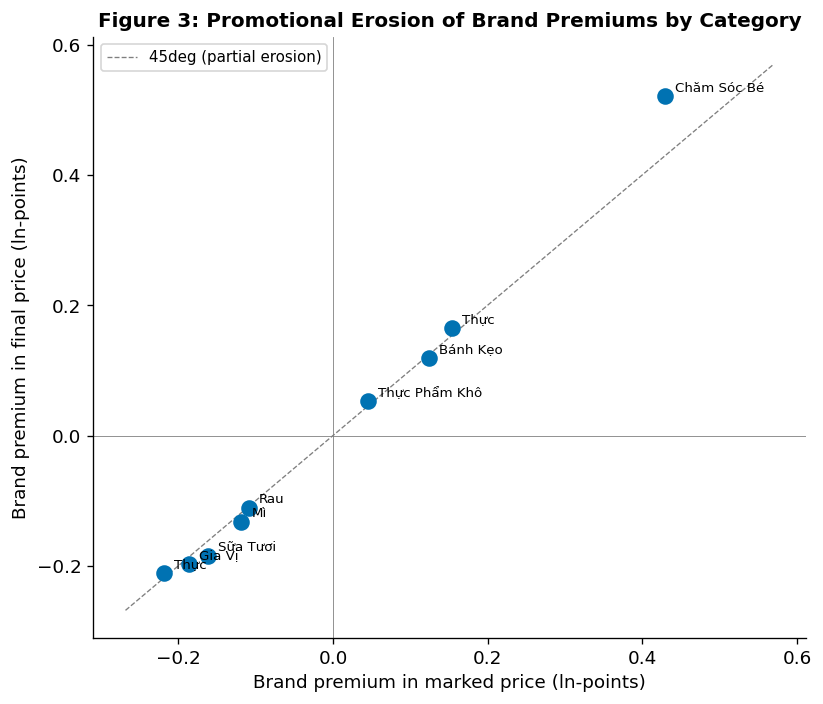

Saved Fig 3


In [7]:
cat_results_final  = {}
cat_results_marked = {}

cat_counts = reg_df.groupby('parent_category').size()
eligible = cat_counts[cat_counts >= 20].index.tolist()

SIMPLE_F = (
    'is_branded + is_premium + is_high_recognition + '
    'is_import + is_house_brand + '
    'ln_pack_size + pack_count + has_health_claim + has_freshness_claim + name_length'
)

for cat in eligible:
    sub = reg_df[reg_df['parent_category'] == cat]
    fe = ' + C(subcategory)' if sub['subcategory'].nunique() > 1 else ''
    try:
        mf = smf.ols(f'ln_price_per_unit ~ {SIMPLE_F}{fe}', data=sub).fit()
        mm = smf.ols(f'ln_marked_price_per_unit ~ {SIMPLE_F}{fe}', data=sub).fit()
        cat_results_final[cat]  = mf.params.get('is_branded', np.nan)
        cat_results_marked[cat] = mm.params.get('is_branded', np.nan)
    except Exception:
        pass

cats  = list(cat_results_final.keys())
x_val = [cat_results_marked[c] for c in cats]
y_val = [cat_results_final[c]  for c in cats]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(x_val, y_val, color=COLORS['blue'], s=80, zorder=3)

# 45deg line
lim = [min(x_val + y_val) - 0.05, max(x_val + y_val) + 0.05]
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5, label='45deg (partial erosion)')

for cat, x, y in zip(cats, x_val, y_val):
    short = cat.split()[0] if len(cat) > 15 else cat
    ax.annotate(short, (x, y), textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Brand premium in marked price (ln-points)')
ax.set_ylabel('Brand premium in final price (ln-points)')
ax.set_title('Figure 3: Promotional Erosion of Brand Premiums by Category',
             fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'thesis_fig3_brand_premium_marked_vs_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Fig 3")

In [8]:
# --- Table for Fig 3: Brand premium erosion (marked vs. final) by category ---
rows_f3 = []
for cat in cats:
    bp_marked = cat_results_marked[cat]
    bp_final = cat_results_final[cat]
    # Erosion: how much does the brand premium change from marked → final?
    if abs(bp_marked) > 1e-6:
        erosion_pct = (bp_marked - bp_final) / abs(bp_marked) * 100
    else:
        erosion_pct = np.nan
    # Direction: does promotion amplify or erode the brand effect?
    if bp_marked < 0 and bp_final < bp_marked:
        direction = 'amplified (more negative)'
    elif bp_marked < 0 and bp_final > bp_marked:
        direction = 'eroded (less negative)'
    elif bp_marked > 0 and bp_final < bp_marked:
        direction = 'eroded (smaller premium)'
    elif bp_marked > 0 and bp_final > bp_marked:
        direction = 'amplified (larger premium)'
    else:
        direction = 'unchanged'
    
    cat_n = len(reg_df[reg_df['parent_category'] == cat])
    rows_f3.append({
        'category': cat,
        'n': cat_n,
        'brand_premium_marked': round(bp_marked, 4),
        'brand_premium_final': round(bp_final, 4),
        'pct_premium_marked': round((np.exp(bp_marked) - 1) * 100, 1),
        'pct_premium_final': round((np.exp(bp_final) - 1) * 100, 1),
        'erosion_pct': round(erosion_pct, 1),
        'erosion_direction': direction,
    })

table_fig3 = pd.DataFrame(rows_f3)
table_fig3.to_csv(OUT / 'thesis_table_brand_erosion.csv', index=False, encoding='utf-8-sig')
print("Table for Fig 3: Brand Premium Erosion (Marked -> Final)")
print("erosion_pct = how much of marked-price brand effect is lost at checkout\n")
print(f"Saved -> output/thesis_table_brand_erosion.csv\n")
table_fig3

Table for Fig 3: Brand Premium Erosion (Marked -> Final)
erosion_pct = how much of marked-price brand effect is lost at checkout

Saved -> output/thesis_table_brand_erosion.csv



,category,n,brand_premium_marked,brand_premium_final,pct_premium_marked,pct_premium_final,erosion_pct,erosion_direction
0,Bánh Kẹo,550,0.1244,0.1190,13.2,12.6,4.3,eroded (smaller premium)
1,Chăm Sóc Bé,34,0.4300,0.5203,53.7,68.3,-21.0,amplified (larger premium)
2,Gia Vị,294,-0.1866,-0.1971,-17.0,-17.9,5.6,amplified (more negative)
3,Mì - Thực Phẩm Ăn Liền,224,-0.1184,-0.1329,-11.2,-12.4,12.2,amplified (more negative)
4,Rau - Củ - Trái Cây,124,-0.1092,-0.1111,-10.3,-10.5,1.7,amplified (more negative)
5,Sữa Tươi,330,-0.1617,-0.1846,-14.9,-16.9,14.1,amplified (more negative)
6,Thực Phẩm Chế Biến,167,0.1544,0.1657,16.7,18.0,-7.3,amplified (larger premium)
7,Thực Phẩm Khô,170,0.0455,0.0522,4.7,5.4,-14.8,amplified (larger premium)
8,Thực Phẩm Đông Lạnh,131,-0.2183,-0.2111,-19.6,-19.0,-3.3,eroded (less negative)


## Figure 4: Premium Heatmap — Attributes × Categories

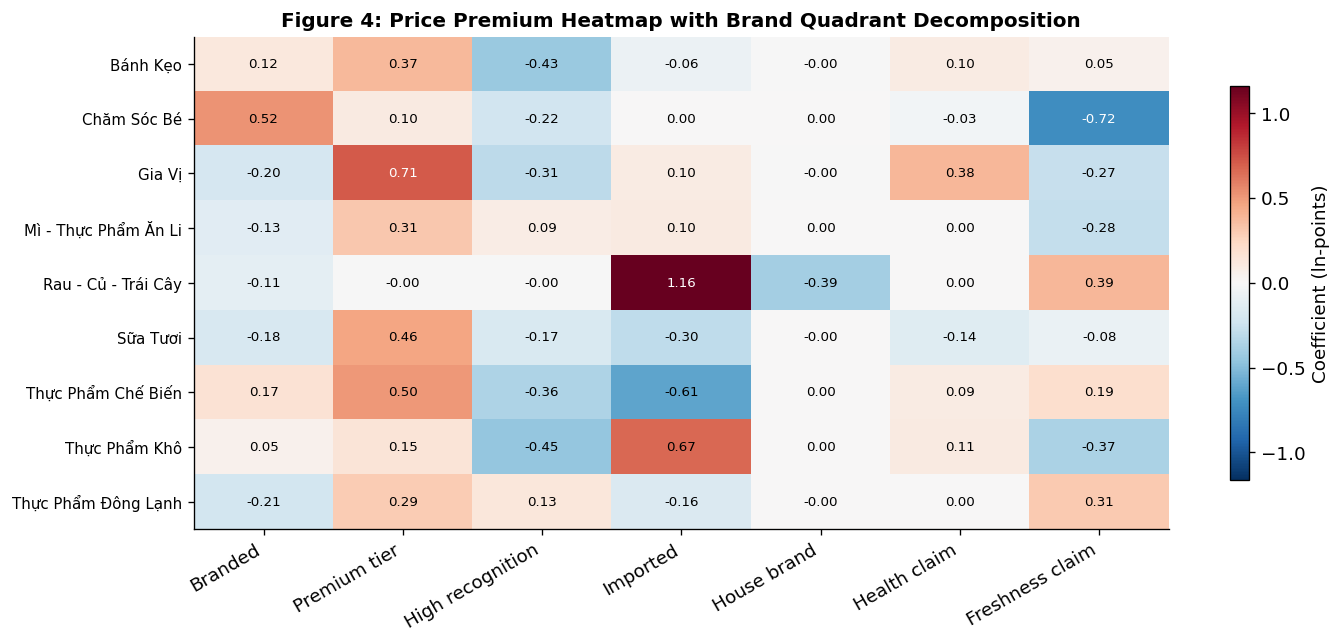

Saved Fig 4


In [9]:
ATTR_VARS = ['is_branded', 'is_premium', 'is_high_recognition', 'is_import', 'is_house_brand', 'has_health_claim', 'has_freshness_claim']
ATTR_LABELS = ['Branded', 'Premium tier', 'High recognition', 'Imported', 'House brand', 'Health claim', 'Freshness claim']

heatmap_data = pd.DataFrame(index=eligible, columns=ATTR_VARS, dtype=float)

for cat in eligible:
    sub = reg_df[reg_df['parent_category'] == cat]
    fe = ' + C(subcategory)' if sub['subcategory'].nunique() > 1 else ''
    try:
        m = smf.ols(f'ln_price_per_unit ~ {SIMPLE_F}{fe}', data=sub).fit()
        for v in ATTR_VARS:
            heatmap_data.loc[cat, v] = m.params.get(v, np.nan)
    except Exception:
        pass

heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(12, max(4, len(eligible) * 0.5 + 1)))

vmax = heatmap_data.abs().max().max()
im = ax.imshow(
    heatmap_data.values,
    cmap='RdBu_r', aspect='auto',
    vmin=-vmax, vmax=vmax,
)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Coefficient (ln-points)')

for i in range(len(eligible)):
    for j in range(len(ATTR_VARS)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(val) > vmax * 0.6 else 'black')

ax.set_xticks(range(len(ATTR_VARS)))
ax.set_xticklabels(ATTR_LABELS, rotation=30, ha='right')
ax.set_yticks(range(len(eligible)))
ax.set_yticklabels([c[:20] for c in eligible], fontsize=9)
ax.set_title('Figure 4: Price Premium Heatmap with Brand Quadrant Decomposition', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'thesis_fig4_premium_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Fig 4")

In [10]:
# --- Table for Fig 4: Premium heatmap with p-values and significance ---
# Build per-category models and collect coefficients + p-values
heatmap_pvals = pd.DataFrame(index=eligible, columns=ATTR_VARS, dtype=float)
heatmap_coefs = heatmap_data.copy()  # already computed above

for cat in eligible:
    sub = reg_df[reg_df['parent_category'] == cat]
    fe = ' + C(subcategory)' if sub['subcategory'].nunique() > 1 else ''
    try:
        m = smf.ols(f'ln_price_per_unit ~ {SIMPLE_F}{fe}', data=sub).fit()
        for v in ATTR_VARS:
            heatmap_pvals.loc[cat, v] = m.pvalues.get(v, np.nan)
    except Exception:
        pass

heatmap_pvals = heatmap_pvals.astype(float)

# Build long-format table
rows_f4 = []
for cat in eligible:
    cat_n = len(reg_df[reg_df['parent_category'] == cat])
    for var, label in zip(ATTR_VARS, ATTR_LABELS):
        coef = heatmap_coefs.loc[cat, var]
        pval = heatmap_pvals.loc[cat, var]
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        rows_f4.append({
            'category': cat,
            'n': cat_n,
            'attribute': label,
            'coefficient': round(coef, 4) if not np.isnan(coef) else np.nan,
            'pct_effect': round((np.exp(coef) - 1) * 100, 1) if not np.isnan(coef) else np.nan,
            'p_value': round(pval, 4) if not np.isnan(pval) else np.nan,
            'significance': stars,
        })

# Add pooled row for reference
for var, label in zip(ATTR_VARS, ATTR_LABELS):
    coef = model_final.params.get(var, np.nan)
    pval = model_final.pvalues.get(var, np.nan)
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    rows_f4.append({
        'category': '(Pooled)',
        'n': len(reg_df),
        'attribute': label,
        'coefficient': round(coef, 4),
        'pct_effect': round((np.exp(coef) - 1) * 100, 1),
        'p_value': round(pval, 4),
        'significance': stars,
    })

table_fig4 = pd.DataFrame(rows_f4)
table_fig4.to_csv(OUT / 'thesis_table_premium_heatmap.csv', index=False, encoding='utf-8-sig')
print("Table for Fig 4: Premium Heatmap (long format with p-values)")
print(f"Saved -> output/thesis_table_premium_heatmap.csv\n")

# Display as pivot for readability
pivot = table_fig4.pivot_table(
    index='category', columns='attribute',
    values='coefficient', sort=False
).round(4)
print("Coefficient pivot:")
pivot

Table for Fig 4: Premium Heatmap (long format with p-values)
Saved -> output/thesis_table_premium_heatmap.csv

Coefficient pivot:


attribute,Branded,Premium tier,High recognition,Imported,House brand,Health claim,Freshness claim
category,,,,,,,
Bánh Kẹo,0.1190,0.3737,-0.4318,-0.0645,0.0000,0.0997,0.0507
Chăm Sóc Bé,0.5203,0.1012,-0.2242,0.0000,0.0000,-0.0277,-0.7240
Gia Vị,-0.1971,0.7101,-0.3062,0.0996,0.0000,0.3822,-0.2669
Mì - Thực Phẩm Ăn Liền,-0.1329,0.3122,0.0852,0.1022,0.0000,0.0000,-0.2810
Rau - Củ - Trái Cây,-0.1111,0.0000,0.0000,1.1623,-0.3928,0.0000,0.3904
Sữa Tươi,-0.1846,0.4553,-0.1750,-0.2963,0.0000,-0.1409,-0.0776
Thực Phẩm Chế Biến,0.1657,0.5032,-0.3610,-0.6135,0.0000,0.0933,0.1925
Thực Phẩm Khô,0.0522,0.1519,-0.4457,0.6673,0.0000,0.1066,-0.3662
Thực Phẩm Đông Lạnh,-0.2111,0.2948,0.1275,-0.1646,0.0000,0.0000,0.3078


## Figure 5: Promotion Penetration vs. Brand Premium
Cross-category scatter: does higher promotion penetration correlate with higher brand premium?
Tests the 'promotional pricing paradox' hypothesis.

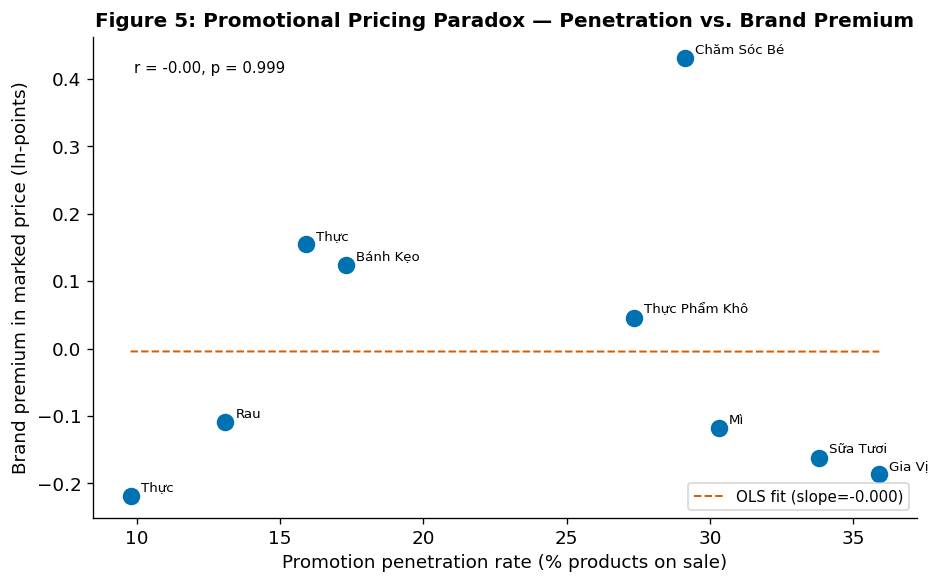

Saved Fig 5


In [11]:
# Per-category: avg promo_rate and brand premium in marked price
cat_promo = df.groupby('parent_category')['promo_rate'].mean()

# Use marked-price brand premium (shows full sticker premium before discounts)
brand_premiums_marked = {}
for cat in eligible:
    sub = reg_df[reg_df['parent_category'] == cat]
    fe  = ' + C(subcategory)' if sub['subcategory'].nunique() > 1 else ''
    try:
        mm = smf.ols(f'ln_marked_price_per_unit ~ {SIMPLE_F}{fe}', data=sub).fit()
        brand_premiums_marked[cat] = mm.params.get('is_branded', np.nan)
    except Exception:
        pass

plot_cats   = [c for c in eligible if c in brand_premiums_marked and c in cat_promo.index]
x_promo     = [cat_promo[c] * 100 for c in plot_cats]  # as %
y_premium   = [brand_premiums_marked[c] for c in plot_cats]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_promo, y_premium, color=COLORS['blue'], s=90, zorder=3)

for cat, x, y in zip(plot_cats, x_promo, y_premium):
    short = cat.split()[0] if len(cat) > 15 else cat
    ax.annotate(short, (x, y), textcoords='offset points', xytext=(6, 3), fontsize=8)

# Regression line
if len(x_promo) >= 3:
    m, b = np.polyfit(x_promo, y_premium, 1)
    x_line = np.linspace(min(x_promo), max(x_promo), 50)
    ax.plot(x_line, m * x_line + b, '--', color=COLORS['red'], linewidth=1.2,
            label=f'OLS fit (slope={m:.3f})')
    r, p = stats.pearsonr(x_promo, y_premium)
    ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.3f}',
            transform=ax.transAxes, va='top', fontsize=9)

ax.set_xlabel('Promotion penetration rate (% products on sale)')
ax.set_ylabel('Brand premium in marked price (ln-points)')
ax.set_title('Figure 5: Promotional Pricing Paradox — Penetration vs. Brand Premium',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'thesis_fig5_promo_vs_brand_premium.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Fig 5")

In [12]:
# --- Table for Fig 5: Promo penetration vs. brand premium (per category) ---
rows_f5 = []
for cat in plot_cats:
    # Also get final-price brand premium for comparison
    bp_final = cat_results_final.get(cat, np.nan)
    bp_marked = brand_premiums_marked.get(cat, np.nan)
    disc = df[df['parent_category'] == cat]['avg_discount_depth'].mean()
    rows_f5.append({
        'category': cat,
        'n': len(reg_df[reg_df['parent_category'] == cat]),
        'promo_penetration_pct': round(cat_promo[cat] * 100, 1),
        'brand_premium_marked': round(bp_marked, 4),
        'brand_premium_final': round(bp_final, 4),
        'pct_effect_marked': round((np.exp(bp_marked) - 1) * 100, 1),
        'pct_effect_final': round((np.exp(bp_final) - 1) * 100, 1),
        'avg_discount_depth_pct': round(disc * 100, 1) if not np.isnan(disc) else np.nan,
    })

table_fig5 = pd.DataFrame(rows_f5)

# Add correlation statistics as a summary row
r, p_corr = stats.pearsonr(x_promo, y_premium)
slope, intercept = np.polyfit(x_promo, y_premium, 1)
summary_row = pd.DataFrame([{
    'category': '--- CORRELATION ---',
    'n': len(plot_cats),
    'promo_penetration_pct': np.nan,
    'brand_premium_marked': np.nan,
    'brand_premium_final': np.nan,
    'pct_effect_marked': np.nan,
    'pct_effect_final': np.nan,
    'avg_discount_depth_pct': np.nan,
}])
table_fig5 = pd.concat([table_fig5, summary_row], ignore_index=True)

table_fig5.to_csv(OUT / 'thesis_table_promo_vs_premium.csv', index=False, encoding='utf-8-sig')
print("Table for Fig 5: Promo Penetration vs. Brand Premium")
print(f"Pearson r = {r:.3f}, p = {p_corr:.4f}")
print(f"OLS slope = {slope:.4f} (brand premium change per 1pp promo increase)")
print(f"\nSaved -> output/thesis_table_promo_vs_premium.csv\n")
table_fig5

Table for Fig 5: Promo Penetration vs. Brand Premium
Pearson r = -0.000, p = 0.9991
OLS slope = -0.0000 (brand premium change per 1pp promo increase)

Saved -> output/thesis_table_promo_vs_premium.csv



,category,n,promo_penetration_pct,brand_premium_marked,brand_premium_final,pct_effect_marked,pct_effect_final,avg_discount_depth_pct
0,Bánh Kẹo,550,17.3,0.1244,0.1190,13.2,12.6,19.1
1,Chăm Sóc Bé,34,29.1,0.4300,0.5203,53.7,68.3,16.3
2,Gia Vị,294,35.9,-0.1866,-0.1971,-17.0,-17.9,15.7
3,Mì - Thực Phẩm Ăn Liền,224,30.3,-0.1184,-0.1329,-11.2,-12.4,14.2
4,Rau - Củ - Trái Cây,124,13.1,-0.1092,-0.1111,-10.3,-10.5,18.0
5,Sữa Tươi,330,33.8,-0.1617,-0.1846,-14.9,-16.9,12.5
6,Thực Phẩm Chế Biến,167,15.9,0.1544,0.1657,16.7,18.0,16.5
7,Thực Phẩm Khô,170,27.3,0.0455,0.0522,4.7,5.4,15.1
8,Thực Phẩm Đông Lạnh,131,9.8,-0.2183,-0.2111,-19.6,-19.0,16.2
9,--- CORRELATION ---,9,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import os

print("All thesis figures and tables saved to output/\n")

print("Figures:")
figs = sorted(f for f in os.listdir('../output') if f.startswith('thesis_fig'))
for f in figs:
    print(f"  {f}")

print("\nNumerical Tables:")
tables = sorted(f for f in os.listdir('../output') if f.startswith('thesis_table'))
for f in tables:
    print(f"  {f}")

All thesis figures and tables saved to output/

Figures:
  thesis_fig1_brand_price_distribution.png
  thesis_fig2_forest_plot.png
  thesis_fig3_brand_premium_marked_vs_final.png
  thesis_fig4_premium_heatmap.png
  thesis_fig5_promo_vs_brand_premium.png
  thesis_figD1_gap_over_time.png
  thesis_figD2_final_vs_marked_gap.png
  thesis_figD3_tet_window.png
  thesis_figD4_gap_by_period.png
  thesis_figD5_quadrant_gap_over_time.png

Numerical Tables:
  thesis_table1_descriptive.csv
  thesis_table2_pooled_regression.csv
  thesis_table3_category_regression.csv
  thesis_table_brand_distribution.csv
  thesis_table_brand_erosion.csv
  thesis_table_brand_profiles.csv
  thesis_table_forest_plot.csv
  thesis_table_premium_heatmap.csv
  thesis_table_promo_vs_premium.csv
  thesis_table_vif.csv
